# Map Texture

Map the topology-space warped pattern images onto each flat origami net.

In [1]:
import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from origami_texturing.paths import OUTPUT_DIR, PROCESSED_DATA_DIR, RAW_DATA_DIR

pose_names = ["wingup", "wingdown"]

topology_paths = {
    pose_name: RAW_DATA_DIR / f"dove-{pose_name}-topology.json"
    for pose_name in pose_names
}
net_paths = {
    pose_name: RAW_DATA_DIR / f"dove-{pose_name}-net.json"
    for pose_name in pose_names
}
warped_paths = {
    pose_name: PROCESSED_DATA_DIR / f"warped-{pose_name}.png"
    for pose_name in pose_names
}
uv_paths = {
    pose_name: PROCESSED_DATA_DIR / f"uv-{pose_name}.png"
    for pose_name in pose_names
}
texture_path = OUTPUT_DIR / "texture.png"

## Load Faces

In [2]:
def load_json(path: Path) -> dict:
    if not path.exists():
        raise FileNotFoundError(f"JSON not found: {path}")

    with path.open(encoding="utf-8") as f:
        return json.load(f)


def collect_points(data: dict) -> dict[str, np.ndarray]:
    points = {}
    for key in ("vertices", "features", "quaters", "quarters"):
        points.update(data.get(key, {}))
    return {name: np.asarray(xy, dtype=np.float32) for name, xy in points.items()}


def resolve_faces(data: dict) -> dict[str, np.ndarray]:
    points = collect_points(data)
    faces = {}

    for face_name, point_names in data["faces"].items():
        missing_points = [point_name for point_name in point_names if point_name not in points]
        if missing_points:
            raise KeyError(f"{face_name} is missing points: {missing_points}")
        if len(point_names) != 3:
            raise ValueError(f"{face_name} must have exactly 3 points for affine UV mapping")

        faces[face_name] = np.asarray(
            [points[point_name] for point_name in point_names],
            dtype=np.float32,
        )

    return faces


face_data_by_pose = {}

for pose_name in pose_names:
    topology = load_json(topology_paths[pose_name])
    net = load_json(net_paths[pose_name])

    topology_faces_xy = resolve_faces(topology)
    net_faces_uv = resolve_faces(net)

    missing_faces = sorted(set(topology_faces_xy) - set(net_faces_uv))
    if missing_faces:
        raise KeyError(f"{pose_name} net json is missing topology faces: {missing_faces}")

    face_data_by_pose[pose_name] = {
        "topology": topology,
        "net": net,
        "topology_faces_xy": topology_faces_xy,
        "net_faces_uv": net_faces_uv,
    }

    print(
        f"{pose_name}: {len(topology_faces_xy)} topology faces, "
        f"{len(net_faces_uv)} net faces, net resolution={net['resolution']}"
    )

wingup: 6 topology faces, 6 net faces, net resolution=[1024, 1024]
wingdown: 5 topology faces, 5 net faces, net resolution=[1024, 1024]


## Map Topology Texture To Net UV

In [3]:
def load_rgba_image(path: Path) -> Image.Image:
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    return Image.open(path).convert("RGBA")


def make_decalcomanie_y_equals_x(rgba: np.ndarray) -> np.ndarray:
    if rgba.shape[0] != rgba.shape[1]:
        raise ValueError("y=x decalcomanie requires a square UV image")

    rgba_float = rgba.astype(np.float32)
    mirrored = np.transpose(rgba_float, (1, 0, 2))

    alpha = rgba_float[..., 3:4] / 255.0
    mirrored_alpha = mirrored[..., 3:4] / 255.0
    weight_sum = alpha + mirrored_alpha

    rgb = np.divide(
        rgba_float[..., :3] * alpha + mirrored[..., :3] * mirrored_alpha,
        np.maximum(weight_sum, 1e-6),
    )
    output_alpha = np.maximum(alpha, mirrored_alpha) * 255.0

    return np.clip(np.concatenate([rgb, output_alpha], axis=2), 0, 255).astype(np.uint8)


def map_topology_image_to_net_uv(
    topology_image: Image.Image,
    topology: dict,
    net: dict,
    topology_faces_xy: dict[str, np.ndarray],
    net_faces_uv: dict[str, np.ndarray],
    make_symmetric: bool = True,
) -> tuple[Image.Image, list[str]]:
    source_rgba = np.array(topology_image.convert("RGBA"), dtype=np.uint8)
    source_height, source_width = source_rgba.shape[:2]

    topology_width, topology_height = topology["resolution"]
    net_width, net_height = net["resolution"]

    source_scale = np.array(
        [source_width / topology_width, source_height / topology_height],
        dtype=np.float32,
    )
    uv_rgba = np.zeros((net_height, net_width, 4), dtype=np.uint8)
    mapped_faces = []

    for face_name, source_triangle_topology in topology_faces_xy.items():
        source_triangle = source_triangle_topology * source_scale
        destination_triangle = net_faces_uv[face_name]

        transform = cv2.getAffineTransform(
            source_triangle.astype(np.float32),
            destination_triangle.astype(np.float32),
        )
        warped_face = cv2.warpAffine(
            source_rgba,
            transform,
            (net_width, net_height),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=(0, 0, 0, 0),
        )

        face_mask = np.zeros((net_height, net_width), dtype=np.uint8)
        cv2.fillConvexPoly(
            face_mask,
            np.round(destination_triangle).astype(np.int32),
            255,
        )

        pixels = face_mask > 0
        uv_rgba[pixels] = warped_face[pixels]
        mapped_faces.append(face_name)

    if make_symmetric:
        uv_rgba = make_decalcomanie_y_equals_x(uv_rgba)

    return Image.fromarray(uv_rgba, mode="RGBA"), mapped_faces


uv_textures_by_pose = {}

for pose_name in pose_names:
    face_data = face_data_by_pose[pose_name]
    topology_image = load_rgba_image(warped_paths[pose_name])

    uv_image, mapped_faces = map_topology_image_to_net_uv(
        topology_image=topology_image,
        topology=face_data["topology"],
        net=face_data["net"],
        topology_faces_xy=face_data["topology_faces_xy"],
        net_faces_uv=face_data["net_faces_uv"],
        make_symmetric=True,
    )

    uv_image.save(uv_paths[pose_name])
    uv_textures_by_pose[pose_name] = {
        "source": topology_image,
        "image": uv_image,
        "faces": mapped_faces,
        "path": uv_paths[pose_name],
    }

    print(
        f"{pose_name}: mapped {len(mapped_faces)} topology faces "
        f"to a y=x symmetric flat net image -> {uv_paths[pose_name]}"
    )

wingup: mapped 6 topology faces to a y=x symmetric flat net image -> C:\Users\morph\GitHub\origami-texturing\data\processed\uv-wingup.png
wingdown: mapped 5 topology faces to a y=x symmetric flat net image -> C:\Users\morph\GitHub\origami-texturing\data\processed\uv-wingdown.png


## Compose Texture

Resolve overlapping UV pixels by anatomical region: wingdown is on top for the head and beak, while wingup is on top for the tail.

Head + beak overlap (wingdown on top): 26,571 pixels
Tail overlap (wingup on top): 38,486 pixels
Saved final texture to: C:\Users\morph\GitHub\origami-texturing\outputs\texture.png


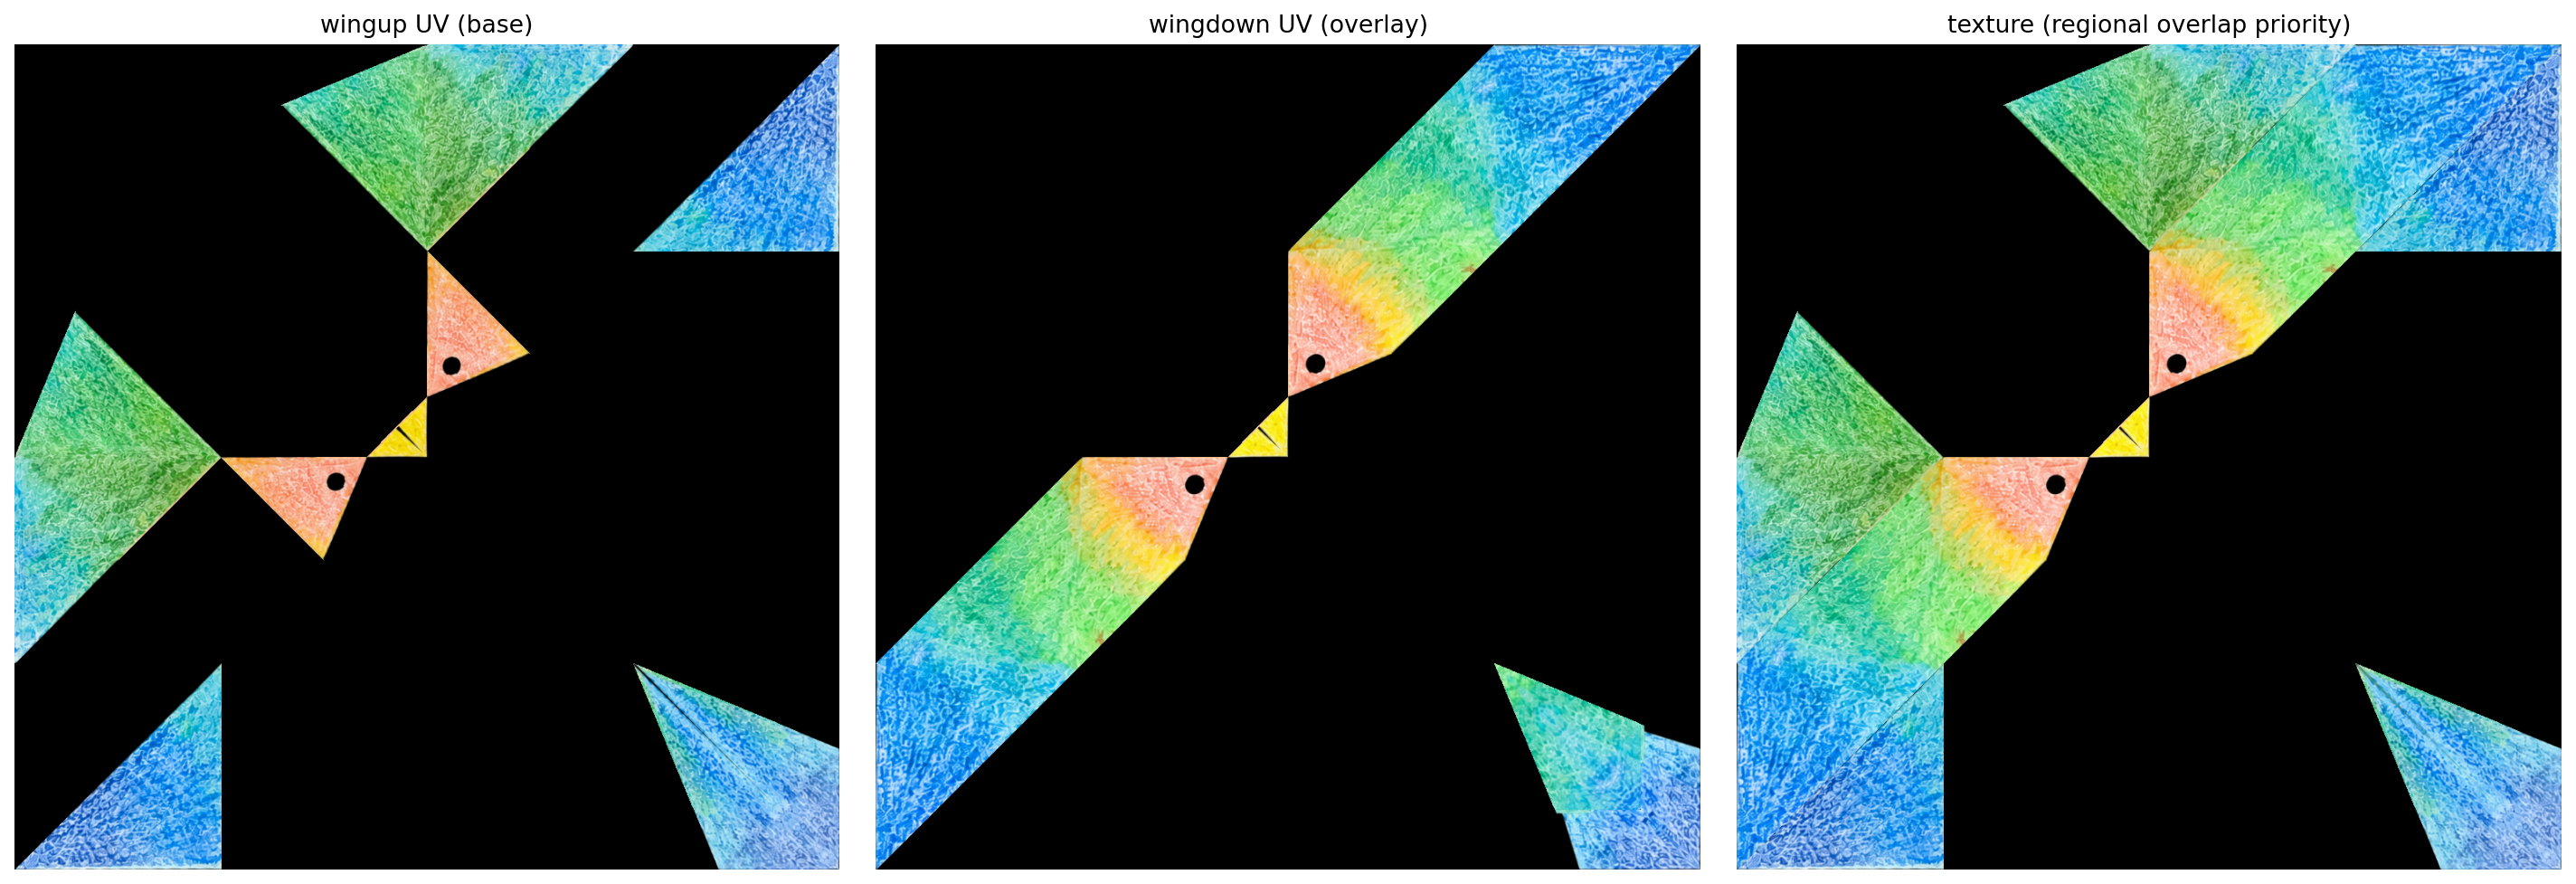

In [4]:
def rgba_on_black(image: Image.Image) -> np.ndarray:
    rgba = np.array(image.convert("RGBA"), dtype=np.float32)
    alpha = rgba[..., 3:4] / 255.0
    return np.clip(rgba[..., :3] * alpha, 0, 255).astype(np.uint8)


def make_symmetric_face_mask(
    face_names: list[str],
    net_faces_uv: dict[str, np.ndarray],
    size: tuple[int, int],
) -> np.ndarray:
    width, height = size
    if width != height:
        raise ValueError("The y=x symmetric UV texture must be square")

    mask = np.zeros((height, width), dtype=np.uint8)
    for face_name in face_names:
        if face_name not in net_faces_uv:
            raise KeyError(f"Net face not found: {face_name}")
        cv2.fillConvexPoly(
            mask,
            np.round(net_faces_uv[face_name]).astype(np.int32),
            255,
        )

    face_mask = mask > 0
    return face_mask | face_mask.T


wingup_uv = uv_textures_by_pose["wingup"]["image"].convert("RGBA")
wingdown_uv = uv_textures_by_pose["wingdown"]["image"].convert("RGBA")

if wingdown_uv.size != wingup_uv.size:
    raise ValueError(f"UV sizes must match: wingdown={wingdown_uv.size}, wingup={wingup_uv.size}")

wingup_rgba = np.asarray(wingup_uv, dtype=np.uint8)
wingdown_rgba = np.asarray(wingdown_uv, dtype=np.uint8)
overlap_mask = (wingup_rgba[..., 3] > 0) & (wingdown_rgba[..., 3] > 0)

head_beak_mask = make_symmetric_face_mask(
    ["head", "beak"],
    face_data_by_pose["wingdown"]["net_faces_uv"],
    wingdown_uv.size,
)
tail_mask = make_symmetric_face_mask(
    ["tail"],
    face_data_by_pose["wingup"]["net_faces_uv"],
    wingup_uv.size,
)

wingdown_on_top = np.asarray(
    Image.alpha_composite(wingup_uv, wingdown_uv),
    dtype=np.uint8,
).copy()
wingup_on_top = np.asarray(
    Image.alpha_composite(wingdown_uv, wingup_uv),
    dtype=np.uint8,
)

texture_rgba = wingdown_on_top
head_beak_overlap = overlap_mask & head_beak_mask
tail_overlap = overlap_mask & tail_mask
texture_rgba[head_beak_overlap] = wingdown_on_top[head_beak_overlap]
texture_rgba[tail_overlap] = wingup_on_top[tail_overlap]
texture_image = Image.fromarray(texture_rgba, mode="RGBA")
texture_image.save(texture_path)

print(f"Head + beak overlap (wingdown on top): {head_beak_overlap.sum():,} pixels")
print(f"Tail overlap (wingup on top): {tail_overlap.sum():,} pixels")
print(f"Saved final texture to: {texture_path}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=160)

axes[0].imshow(rgba_on_black(wingup_uv))
axes[0].set_title("wingup UV (base)")
axes[0].set_axis_off()

axes[1].imshow(rgba_on_black(wingdown_uv))
axes[1].set_title("wingdown UV (overlay)")
axes[1].set_axis_off()

axes[2].imshow(rgba_on_black(texture_image))
axes[2].set_title("texture (regional overlap priority)")
axes[2].set_axis_off()

plt.tight_layout()
plt.show()